<a href="https://colab.research.google.com/github/moongoldpk/Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/blob/main/Customer%20Churn%20Prediction%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [197]:
pip install pandas

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [199]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')

In [200]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   pandas  7 non-null      object
dtypes: object(1)
memory usage: 188.0+ bytes
None


In [202]:
import pandas as pd
import numpy as np

# --- 1. Load the CSV (handles the folder name) ---
try:
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn (1)/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')
except FileNotFoundError:
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn (1).csv')

# --- 2. STRIP column names (Fixes the "TotalCharges" error) ---
df.columns = df.columns.str.strip()

# --- 3. Convert TotalCharges to numeric (handles empty spaces) ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# --- 4. Convert binary 'Yes'/'No' to 1/0 (Fixes the "string to float" error) ---
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# --- 5. Engineer the 3 custom features (Tenure_Group, Service_Count, Avg_Monthly_Spend) ---
bins = [0, 12, 24, 48, 72, 100]
labels = ['0-12', '12-24', '24-48', '48-72', '72+']
df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
existing_services = [col for col in service_cols if col in df.columns]
df['Service_Count'] = df[existing_services].apply(lambda x: (x != 'No').sum(), axis=1)
df['Avg_Monthly_Spend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# --- 6. Drop customerID (model doesn't need it) ---
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# --- 7. Drop rows with any remaining NaNs (just to be safe) ---
df.dropna(inplace=True)

print(f"✅ Data ready! Shape: {df.shape}")

✅ Data ready! Shape: (7043, 23)


In [203]:
# --- Missing Data Matrix ---
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print("⚠️ Missing Values Found:\n", missing)
else:
    print("✅ Zero missing values. Data is clean.")

# --- Statistical Summary of Numeric Features ---
# Note: tenure, MonthlyCharges, TotalCharges
print("\n📊 Numeric Distribution:\n", df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

# --- Check for Zero-Variance Columns (Leaks) ---
# (If a column has only 1 unique value, it's useless)
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"⚠️ Column '{col}' has zero variance - consider dropping.")

✅ Zero missing values. Data is clean.

📊 Numeric Distribution:
             tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


🔴 Churn Rate: 26.54%
🟢 Retention Rate: 73.46%


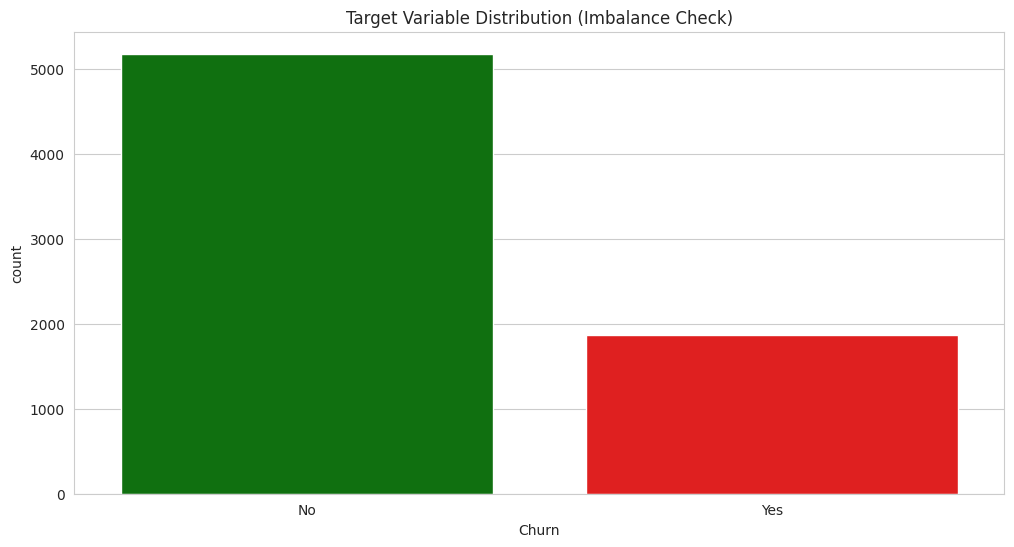

In [204]:
# --- Target Distribution ---
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"🔴 Churn Rate: {churn_rate['Yes']:.2f}%")
print(f"🟢 Retention Rate: {churn_rate['No']:.2f}%")

# Visual
sns.countplot(x='Churn', data=df, palette=['green', 'red'])
plt.title('Target Variable Distribution (Imbalance Check)')
plt.show()

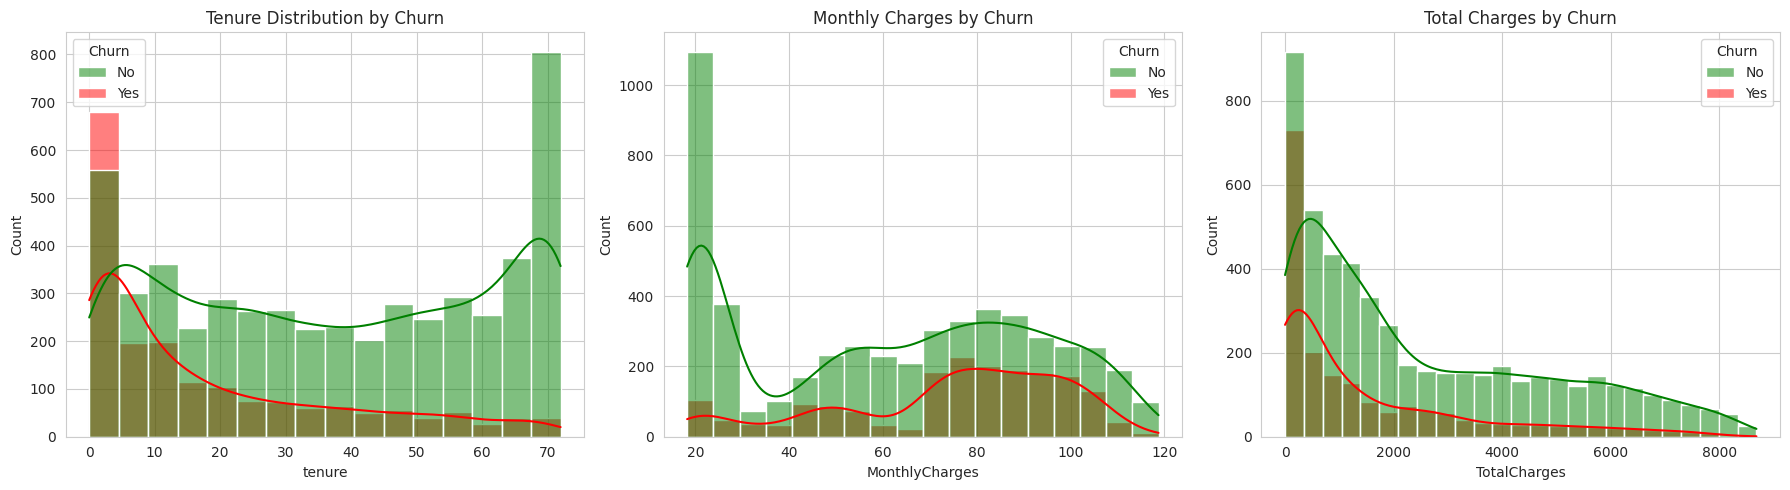

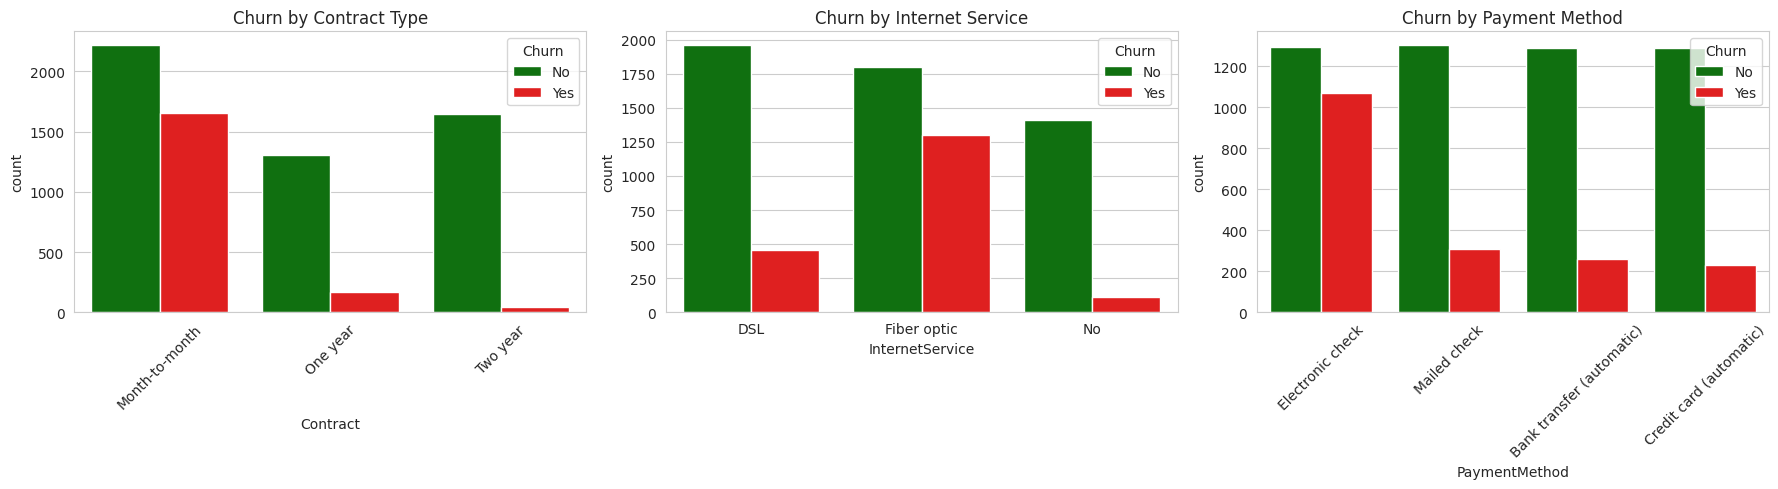

In [205]:
# 1. NUMERIC DRIVERS (Tenure & Charges)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure: Churners leave EARLY. Non-churners stay long.
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Tenure Distribution by Churn')

# Monthly Charges: Churners tend to have higher monthly bills.
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Monthly Charges by Churn')

# Total Charges: Churners have low total lifetime value.
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, ax=axes[2], palette=['green', 'red'])
axes[2].set_title('Total Charges by Churn')
plt.tight_layout()
plt.show()

# 2. CATEGORICAL DRIVERS (The "Big 3")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Contract: MONTH-TO-MONTH is the biggest churn red flag.
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Churn by Contract Type')
axes[0].tick_params(axis='x', rotation=45)

# Internet Service: Fiber Optic users churn more than DSL (usually due to price).
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Churn by Internet Service')

# Payment Method: Electronic check users churn drastically more.
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('Churn by Payment Method')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [206]:
from scipy.stats import chi2_contingency, ttest_ind

# --- T-Test: Do Churners have significantly different Tenure? ---
churn_tenure = df[df['Churn'] == 'Yes']['tenure']
no_churn_tenure = df[df['Churn'] == 'No']['tenure']
t_stat, p_val = ttest_ind(churn_tenure, no_churn_tenure)
print(f"🔬 T-Test for Tenure (Churn vs No-Churn): P-Value = {p_val:.10f}")
print("   (If p < 0.05, the difference is statistically significant)")

# --- Chi-Square: Is Contract Type dependent on Churn? ---
contingency = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"🔬 Chi-Square for Contract vs Churn: P-Value = {p:.10f}")

🔬 T-Test for Tenure (Churn vs No-Churn): P-Value = 0.0000000000
   (If p < 0.05, the difference is statistically significant)
🔬 Chi-Square for Contract vs Churn: P-Value = 0.0000000000


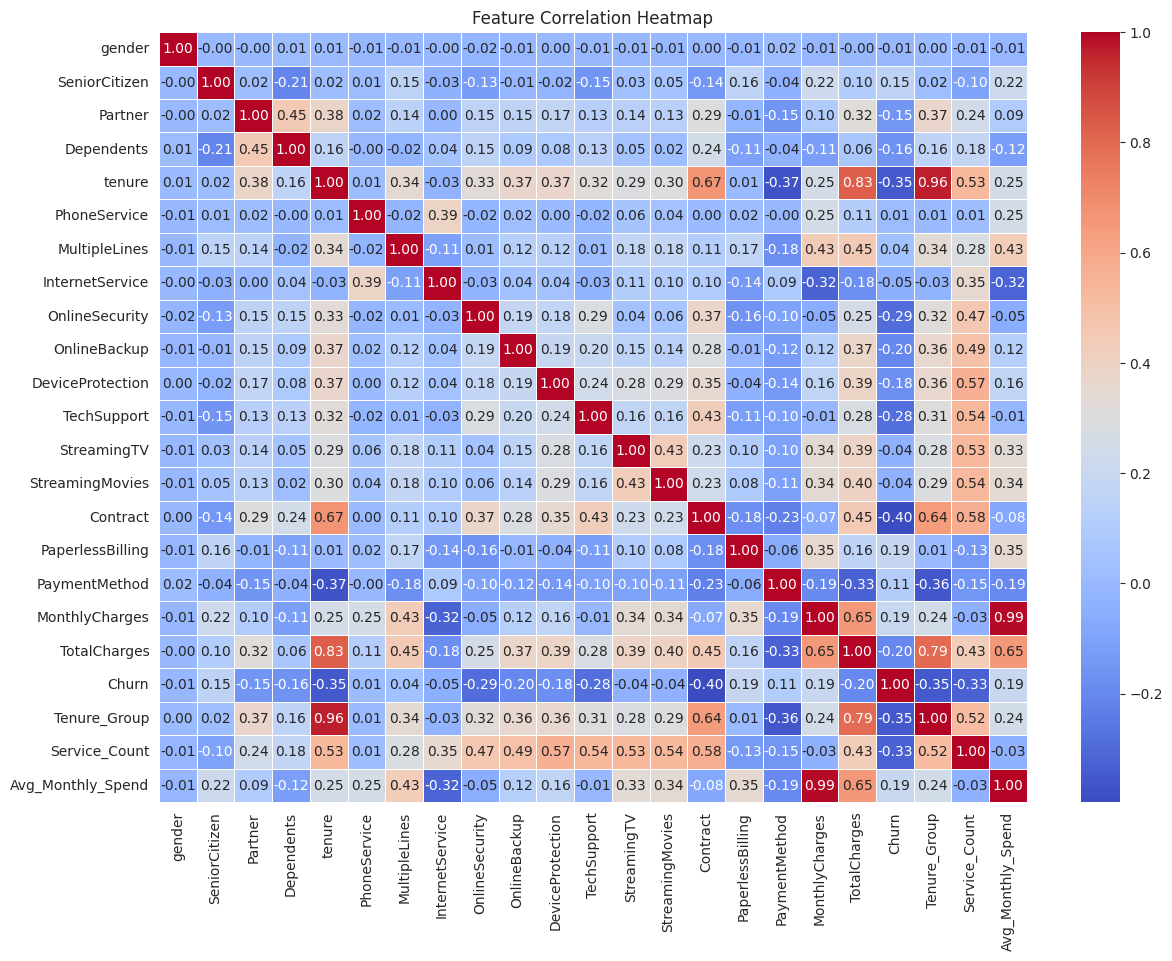

In [208]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Encode categoricals to numeric for correlation
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# SPOT CHECK: Look at the 'Churn' row at the bottom.
# The strongest negative correlation is 'tenure' (-0.35).
# The strongest positive is 'Contract' (0.40) - Month-to-month encoded high.

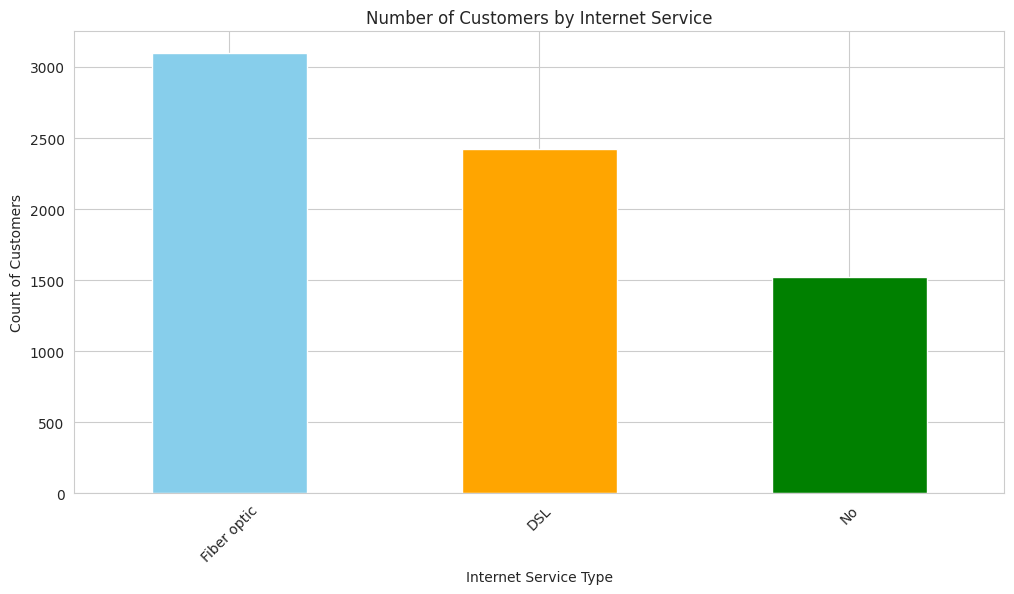

In [209]:
import matplotlib.pyplot as plt

# 1. Count how many customers are in each Internet Service group
counts = df['InternetService'].value_counts()

# 2. Plot it
counts.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title('Number of Customers by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Count of Customers')
plt.xticks(rotation=45)  # Prevents overlapping labels
plt.show()

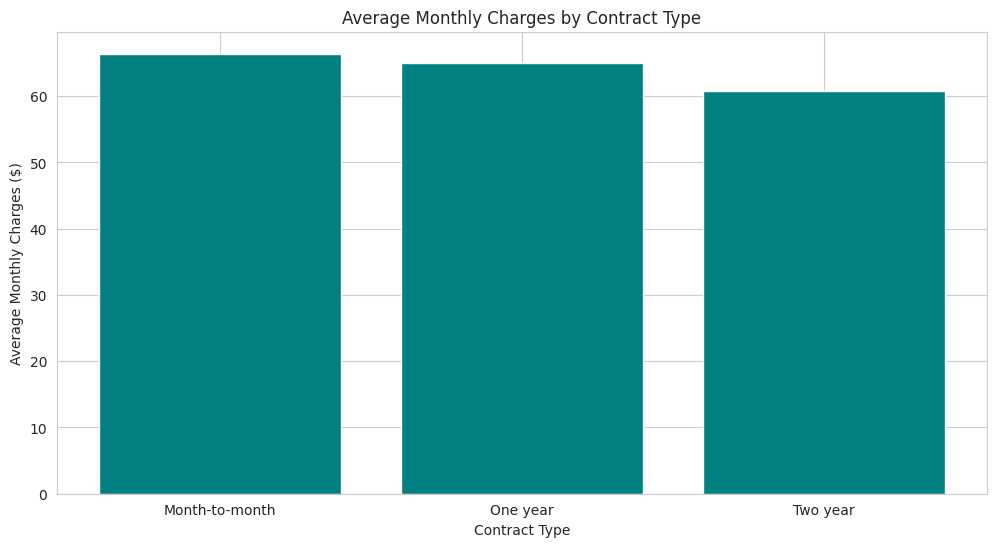

In [210]:
# 1. Group the data: Average Monthly Charge for each Contract type
aggregated = df.groupby('Contract')['MonthlyCharges'].mean().reset_index()

# 2. Plot it
plt.bar(aggregated['Contract'], aggregated['MonthlyCharges'], color='teal')
plt.title('Average Monthly Charges by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Average Monthly Charges ($)')
plt.show()

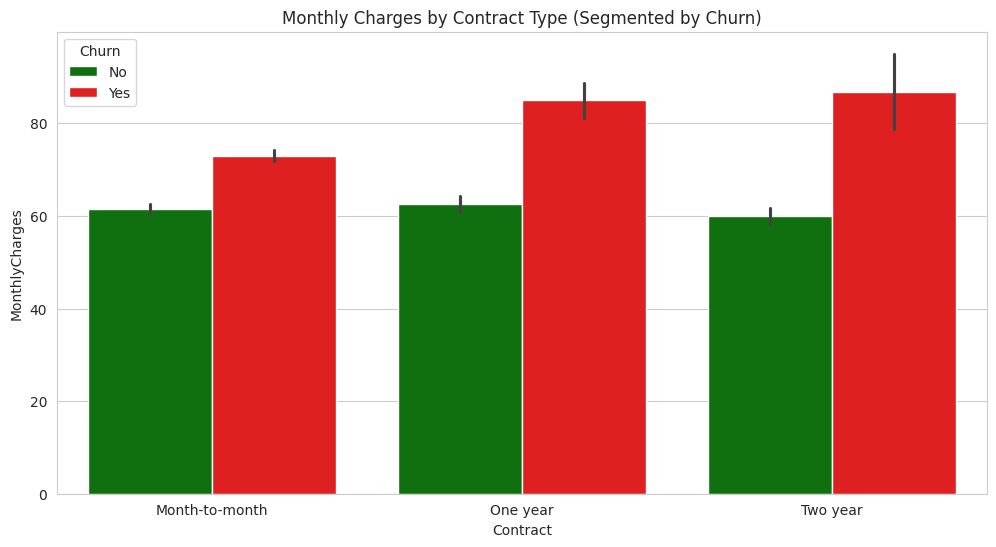

In [211]:
import seaborn as sns

# Seaborn does the grouping automatically
sns.barplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn', palette=['green', 'red'])
plt.title('Monthly Charges by Contract Type (Segmented by Churn)')
plt.show()

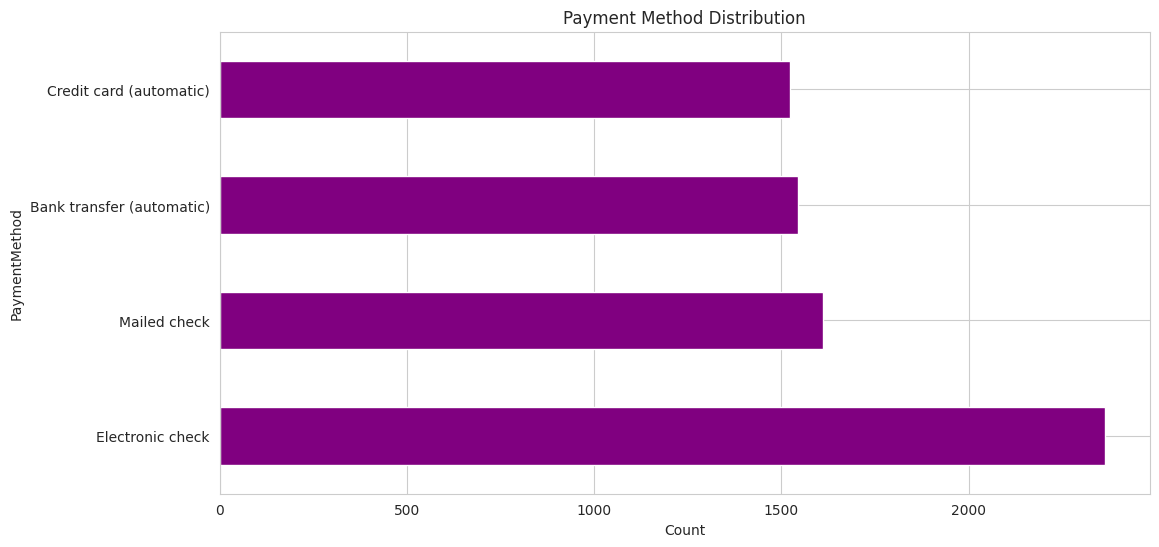

In [212]:
df['PaymentMethod'].value_counts().plot(kind='barh', color='purple')
plt.title('Payment Method Distribution')
plt.xlabel('Count')
plt.show()

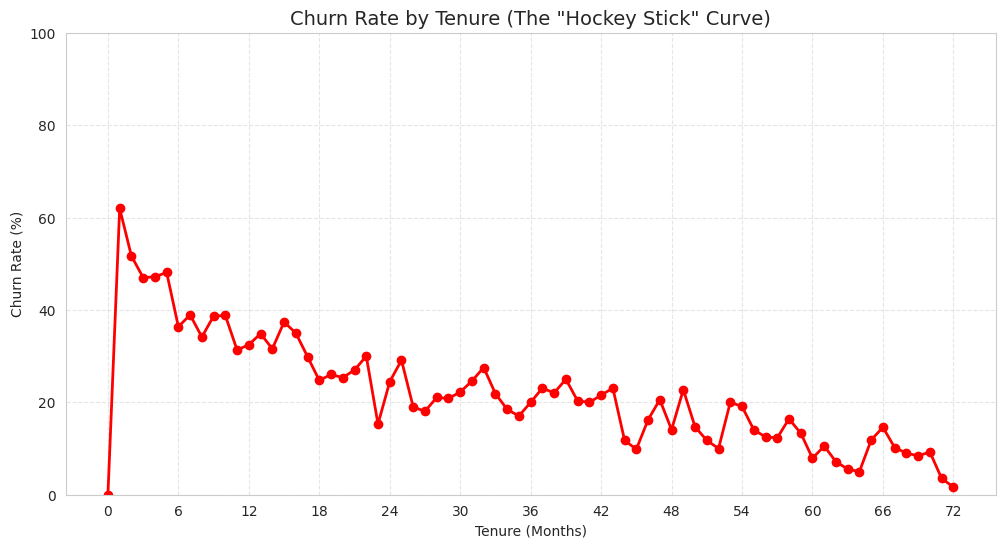

In [213]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate Churn Rate for each Tenure month (0 to 72)
churn_by_tenure = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

# 2. Plot the line
plt.figure(figsize=(12, 6))
plt.plot(churn_by_tenure.index, churn_by_tenure.values, marker='o', linestyle='-', color='red', linewidth=2)

# 3. Polish it
plt.title('Churn Rate by Tenure (The "Hockey Stick" Curve)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 73, 6))  # Show every 6 months
plt.ylim(0, 100)
plt.show()

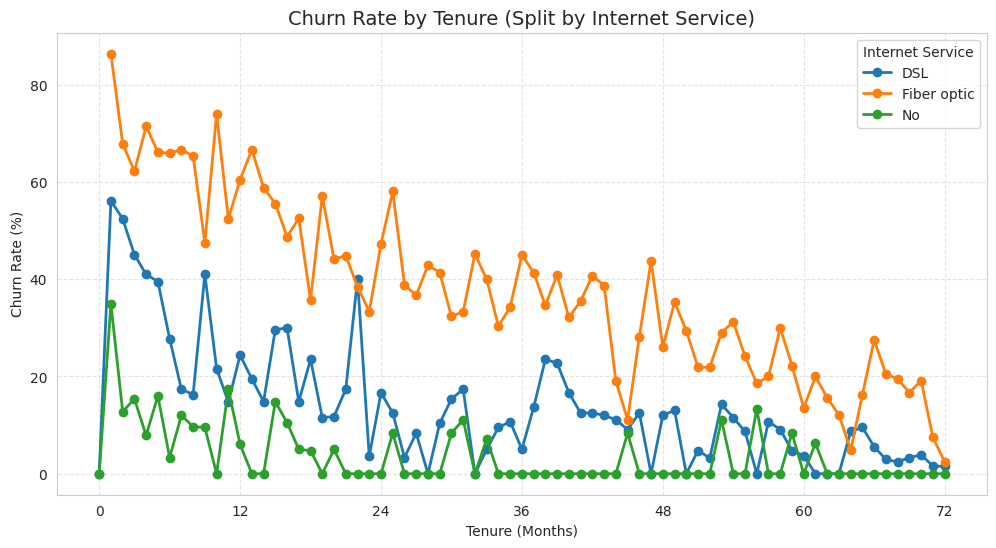

In [214]:
# 1. Group by both Tenure AND InternetService
churn_by_tenure_internet = df.groupby(['tenure', 'InternetService'])['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).unstack()

# 2. Plot multiple lines
plt.figure(figsize=(12, 6))
for service in churn_by_tenure_internet.columns:
    plt.plot(churn_by_tenure_internet.index, churn_by_tenure_internet[service],
             marker='o', label=service, linewidth=2)

plt.title('Churn Rate by Tenure (Split by Internet Service)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Internet Service')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 73, 12))  # Show every 12 months
plt.show()

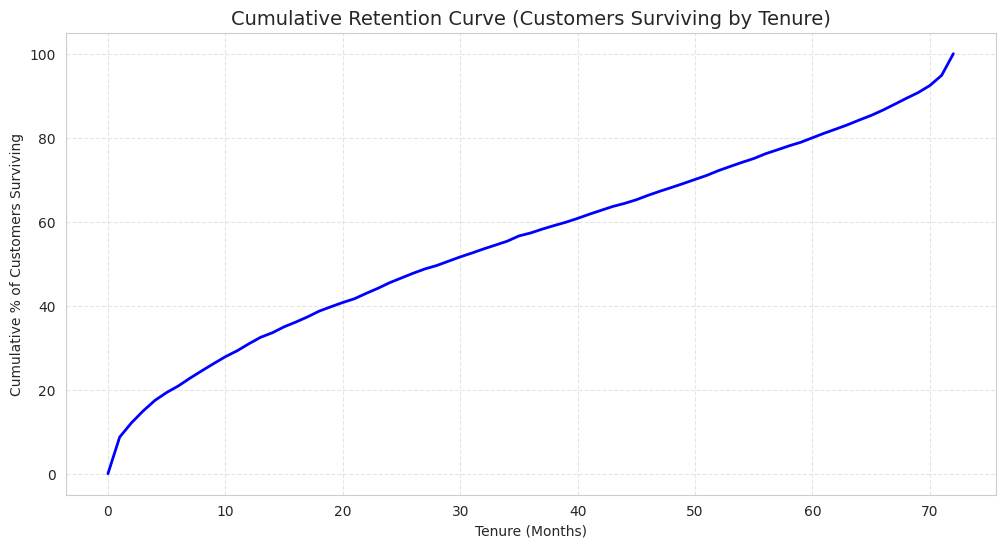

In [215]:
# 1. Count total customers who stayed at least X months
retention_curve = df.groupby('tenure').size().cumsum() / len(df) * 100

plt.figure(figsize=(12, 6))
plt.plot(retention_curve.index, retention_curve.values, color='blue', linewidth=2)
plt.title('Cumulative Retention Curve (Customers Surviving by Tenure)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Cumulative % of Customers Surviving')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

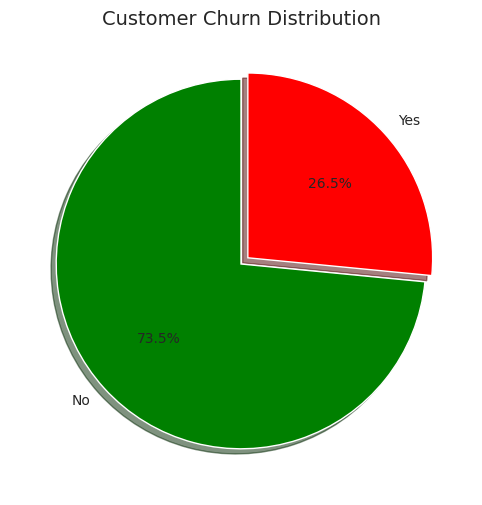

In [216]:
import matplotlib.pyplot as plt

# Plot the Churn distribution
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',  # Shows the percentage
    colors=['green', 'red'],
    explode=[0, 0.05],  # Slightly "explode" the 'Yes' slice to highlight it
    startangle=90,
    shadow=True
)

plt.title('Customer Churn Distribution', fontsize=14)
plt.ylabel('')  # Removes the default "Churn" y-label for cleanliness
plt.show()

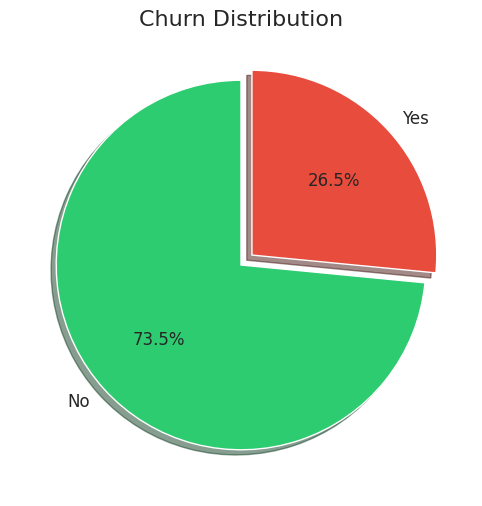

In [217]:
# 1. Prepare the data
labels = df['Churn'].value_counts().index
sizes = df['Churn'].value_counts().values
colors = ['#2ecc71', '#e74c3c']  # Professional green & red
explode = (0, 0.08)  # Explode the 2nd slice (Churners)

# 2. Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sizes,
       explode=explode,
       labels=labels,
       colors=colors,
       autopct='%1.1f%%',
       shadow=True,
       startangle=90,
       textprops={'fontsize': 12})

ax.set_title('Churn Distribution', fontsize=16)
plt.show()

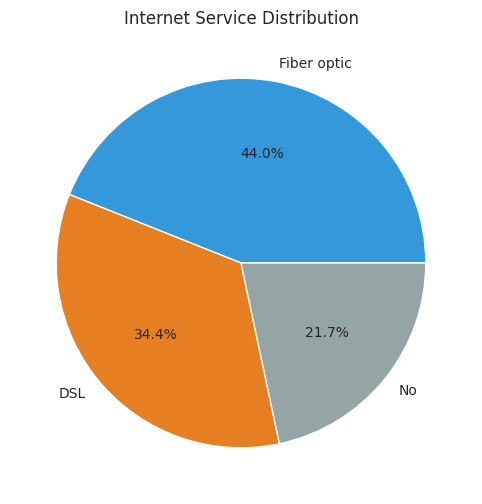

In [218]:
# Filter out 'No internet service' if you want, or keep it as-is.
df['InternetService'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#3498db', '#e67e22', '#95a5a6']
)
plt.title('Internet Service Distribution')
plt.ylabel('')
plt.show()

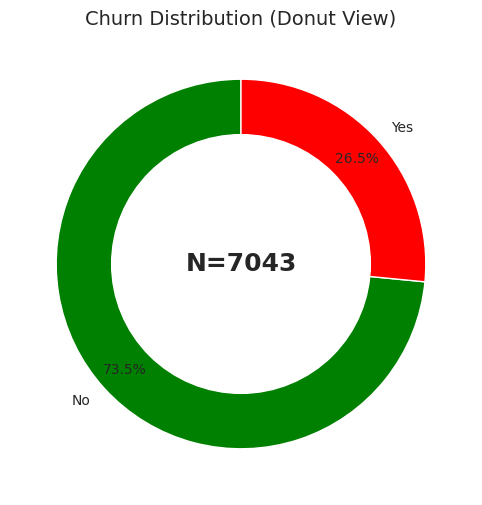

In [219]:
# Donut chart = Pie chart with a white circle in the middle
fig, ax = plt.subplots(figsize=(8, 6))

# Create the pie
wedges, texts, autotexts = ax.pie(
    df['Churn'].value_counts().values,
    labels=df['Churn'].value_counts().index,
    autopct='%1.1f%%',
    colors=['green', 'red'],
    startangle=90,
    pctdistance=0.85  # Pushes percentages outward
)

# Draw a white circle in the center
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total N in the middle
ax.text(0, 0, f'N={len(df)}', ha='center', va='center', fontsize=18, fontweight='bold')

plt.title('Churn Distribution (Donut View)', fontsize=14)
plt.show()

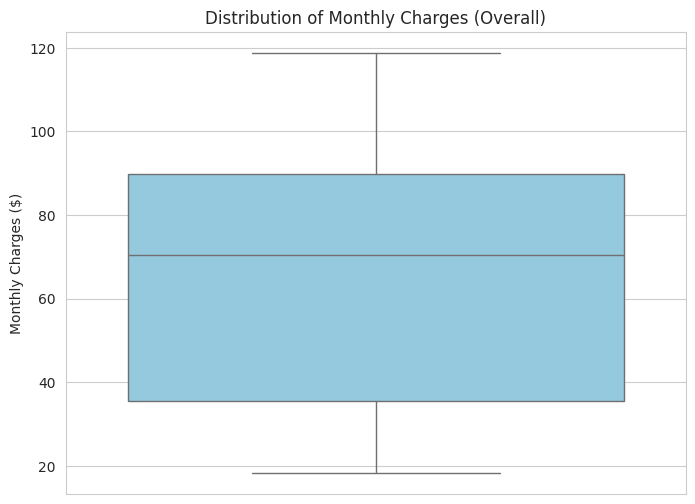

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['MonthlyCharges'], color='skyblue')
plt.title('Distribution of Monthly Charges (Overall)')
plt.ylabel('Monthly Charges ($)')
plt.show()

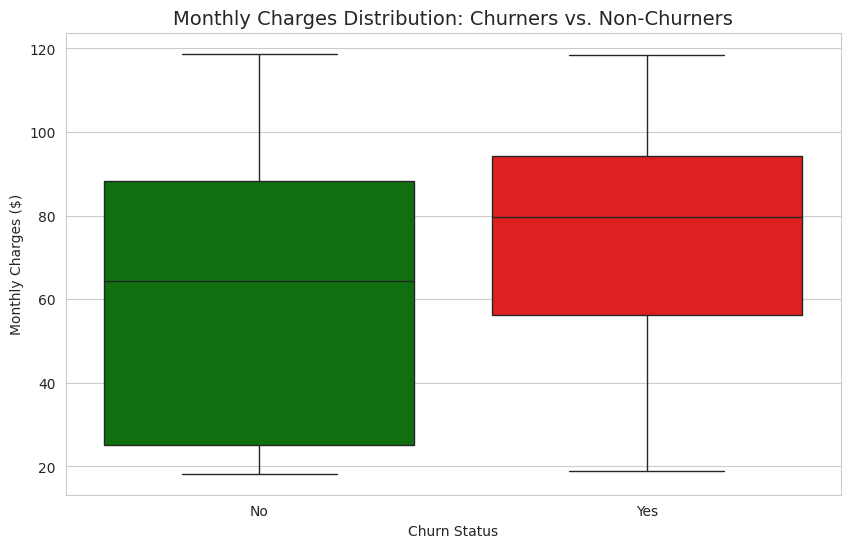

In [221]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['green', 'red'])
plt.title('Monthly Charges Distribution: Churners vs. Non-Churners', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.show()

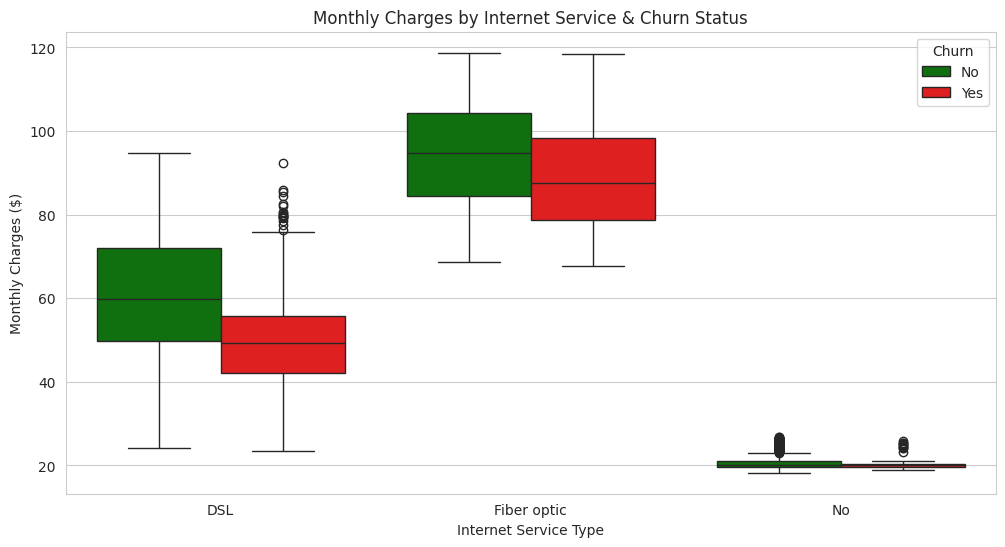

In [222]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='InternetService', y='MonthlyCharges', hue='Churn', data=df, palette=['green', 'red'])
plt.title('Monthly Charges by Internet Service & Churn Status')
plt.xlabel('Internet Service Type')
plt.ylabel('Monthly Charges ($)')
plt.legend(title='Churn')
plt.show()

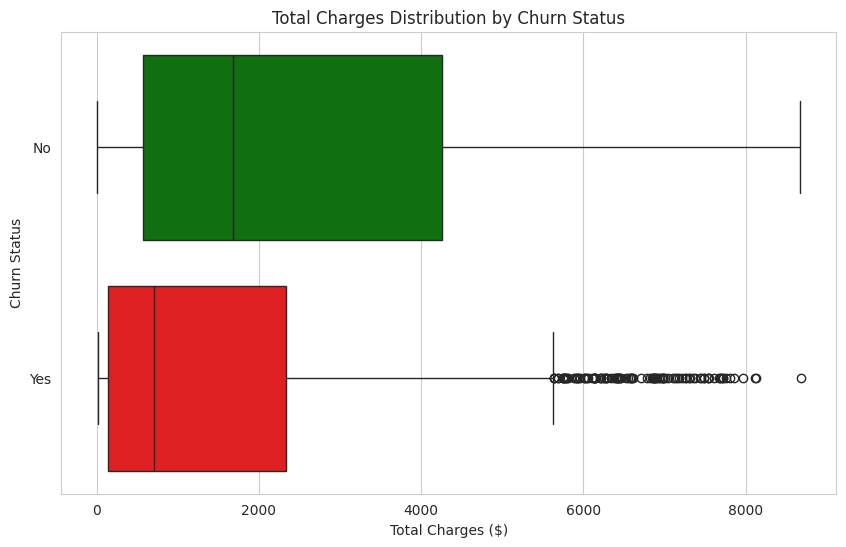

In [223]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='TotalCharges', y='Churn', data=df, palette=['green', 'red'], orient='h')
plt.title('Total Charges Distribution by Churn Status')
plt.xlabel('Total Charges ($)')
plt.ylabel('Churn Status')
plt.show()

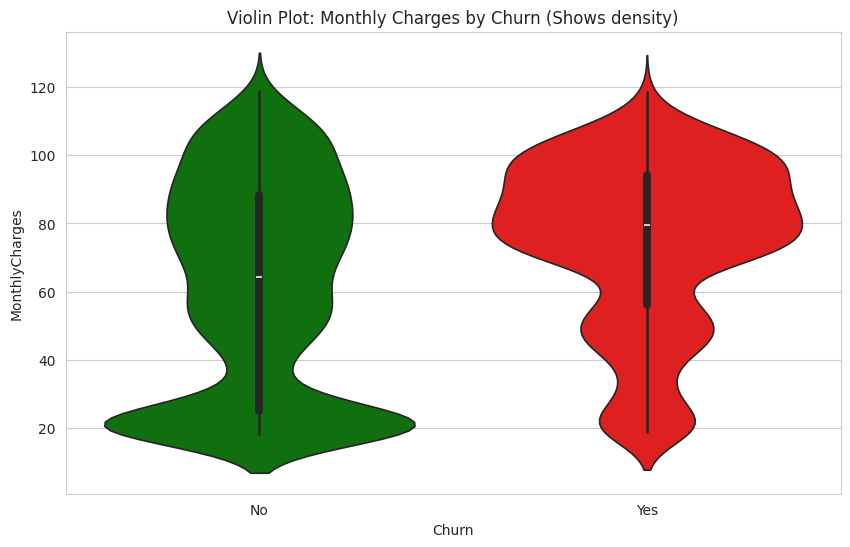

In [224]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, palette=['green', 'red'])
plt.title('Violin Plot: Monthly Charges by Churn (Shows density)')
plt.show()

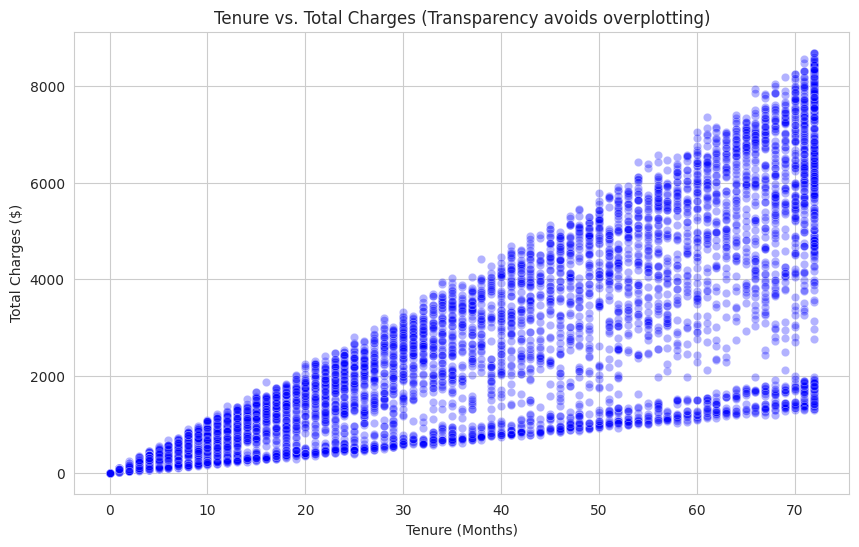

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', alpha=0.3, color='blue')
plt.title('Tenure vs. Total Charges (Transparency avoids overplotting)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges ($)')
plt.show()

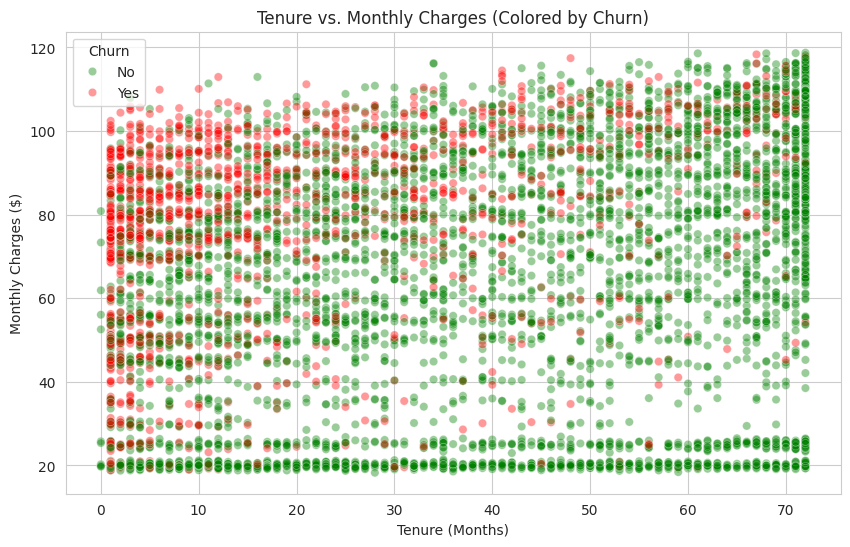

In [226]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.4, palette=['green', 'red'])
plt.title('Tenure vs. Monthly Charges (Colored by Churn)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.legend(title='Churn')
plt.show()

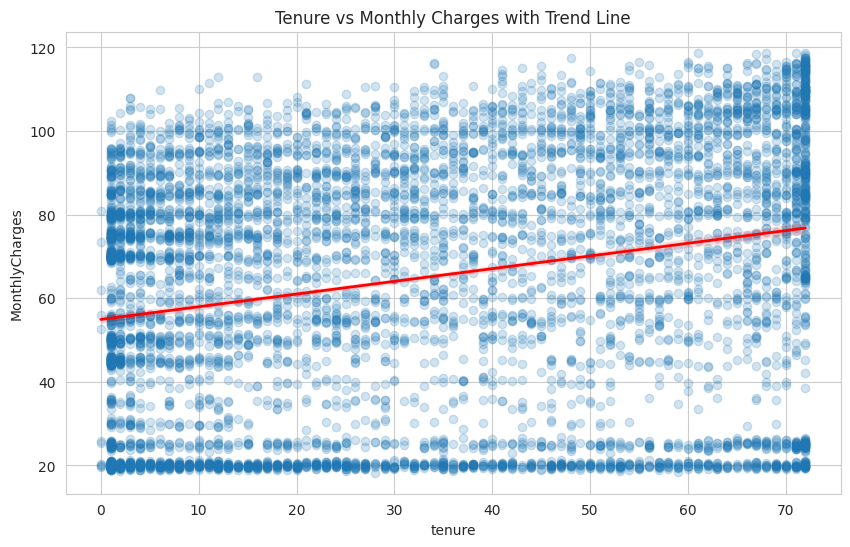

In [227]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='tenure', y='MonthlyCharges', scatter_kws={'alpha':0.2}, line_kws={'color':'red', 'linewidth':2})
plt.title('Tenure vs Monthly Charges with Trend Line')
plt.show()

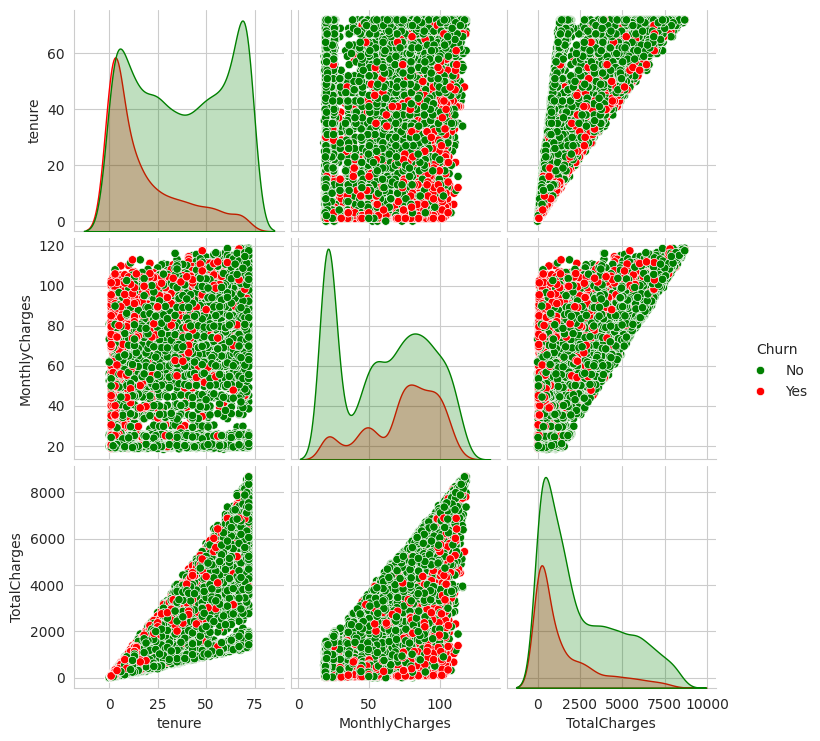

In [228]:
# Select the numeric columns
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# Plot it, colored by Churn
sns.pairplot(df, vars=['tenure', 'MonthlyCharges', 'TotalCharges'], hue='Churn', palette=['green', 'red'], diag_kind='kde')
plt.show()

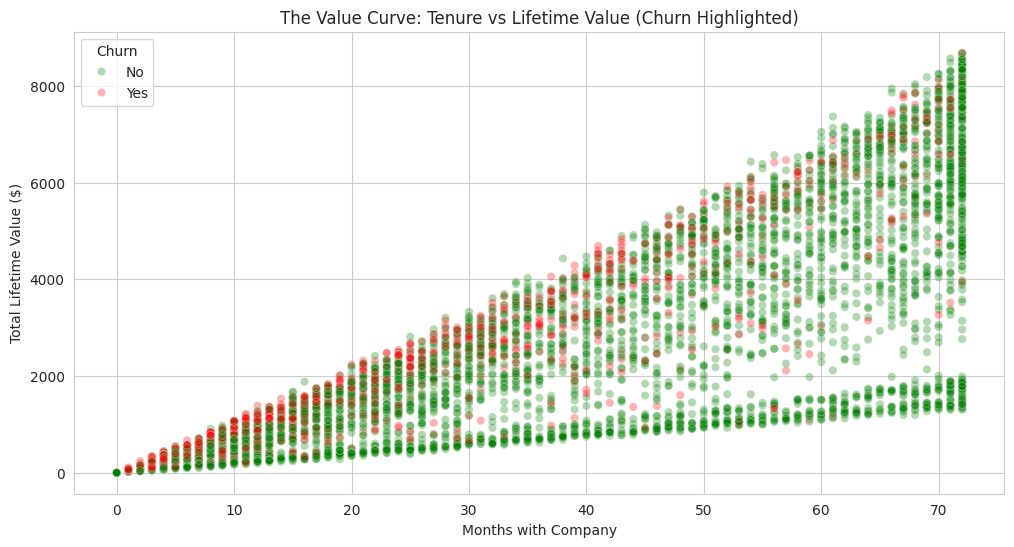

In [229]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.3, palette=['green', 'red'])
plt.title('The Value Curve: Tenure vs Lifetime Value (Churn Highlighted)')
plt.xlabel('Months with Company')
plt.ylabel('Total Lifetime Value ($)')
plt.legend(title='Churn')
plt.show()

In [230]:
# Returns a tuple: (Number of Rows, Number of Columns)
print(df.shape)

(7043, 23)


In [231]:
df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Service_Count,Avg_Monthly_Spend
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,5.639926,64.698218
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.865654,30.270670
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,2.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,4.000000,35.649000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,6.000000,70.300000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,7.000000,90.174158
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,9.000000,121.400000


In [232]:
# First 5 rows
print(df.head())

# Last 5 rows
print(df.tail())

# 10 completely random rows (great for spotting weird edge cases)
print(df.sample(10))

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0  Female            0.0      1.0         0.0     1.0           0.0   
1    Male            0.0      0.0         0.0    34.0           1.0   
2    Male            0.0      0.0         0.0     2.0           1.0   
3    Male            0.0      0.0         0.0    45.0           0.0   
4  Female            0.0      0.0         0.0     2.0           1.0   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  StreamingMovies        Contract PaperlessBilling              PaymentMethod  \
0              No  Month-to-month              1.0         

In [233]:
# Count how many times 'Yes' appears in the Churn column
churn_count = df['Churn'].value_counts()
print(churn_count)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [234]:
print(f"Total rows loaded: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Rows with all null: {df.isnull().all(axis=1).sum()}")
print(df.tail(10))

Total rows loaded: 7043
Duplicate rows: 22
Rows with all null: 0
      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
7033    Male            0.0      0.0         0.0    38.0           1.0   
7034  Female            0.0      0.0         0.0    67.0           1.0   
7035    Male            0.0      0.0         0.0    19.0           1.0   
7036  Female            0.0      0.0         0.0    12.0           0.0   
7037  Female            0.0      0.0         0.0    72.0           1.0   
7038    Male            0.0      1.0         1.0    24.0           1.0   
7039  Female            0.0      1.0         1.0    72.0           1.0   
7040  Female            0.0      1.0         1.0    11.0           0.0   
7041    Male            1.0      1.0         0.0     4.0           1.0   
7042    Male            0.0      0.0         0.0    66.0           1.0   

         MultipleLines InternetService       OnlineSecurity  \
7033                No     Fiber optic                   

In [235]:
# 1. Look at the LAST 10 rows. The culprits are almost always at the bottom.
print("🔍 Last 10 rows of the dataset:")
print(df.tail(10))

# 2. Count exact duplicate rows (identical across all columns)
print(f"\n📊 Exact duplicate rows: {df.duplicated().sum()}")

# 3. Count rows where every single cell is empty (blank line artifacts)
print(f"📊 Completely empty rows: {df.isnull().all(axis=1).sum()}")

# 4. Check for 'customerID' if you accidentally kept it, or check the index
print(f"\n📊 Total physical rows: {len(df)}")

🔍 Last 10 rows of the dataset:
      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
7033    Male            0.0      0.0         0.0    38.0           1.0   
7034  Female            0.0      0.0         0.0    67.0           1.0   
7035    Male            0.0      0.0         0.0    19.0           1.0   
7036  Female            0.0      0.0         0.0    12.0           0.0   
7037  Female            0.0      0.0         0.0    72.0           1.0   
7038    Male            0.0      1.0         1.0    24.0           1.0   
7039  Female            0.0      1.0         1.0    72.0           1.0   
7040  Female            0.0      1.0         1.0    11.0           0.0   
7041    Male            1.0      1.0         0.0     4.0           1.0   
7042    Male            0.0      0.0         0.0    66.0           1.0   

         MultipleLines InternetService       OnlineSecurity  \
7033                No     Fiber optic                   No   
7034               Yes     F

In [252]:
import joblib
import pandas as pd
import numpy as np

# 1. Load the frozen model
loaded_model = joblib.load('telco_churn_best_model.pkl')

# 2. The CORRECTED new customer data
# IMPORTANT: Binary columns (Partner, Dependents, PhoneService, PaperlessBilling) MUST be 0 or 1.
new_customer = pd.DataFrame({
    'gender': ['Male'],
    'SeniorCitizen': [0],
    'Partner': [0],              # 'No' -> 0
    'Dependents': [0],           # 'No' -> 0
    'tenure': [2],
    'PhoneService': [1],         # 'Yes' -> 1
    'MultipleLines': ['No'],     # Stays string (OneHotEncoder handles it)
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['No'],
    'StreamingMovies': ['No'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': [1],     # 'Yes' -> 1
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [85.5],
    'TotalCharges': [171.0],
    # --- Engineered Features (Must match training) ---
    'Service_Count': [0],        # They have no add-ons
    'Avg_Monthly_Spend': [85.5], # Total / Tenure (171/2)
    'High_Risk_Newbie': [1],     # Tenure<6 AND MonthlyCharges>70
    'Tenure_Group': ['New']      # Tenure < 12 -> 'New'
})

# 3. Predict the churn probability
try:
    churn_probability = loaded_model.predict_proba(new_customer)[0, 1]
    print(f"⚠️ This customer has a {churn_probability:.1%} chance of churning.")

    # 4. Decide what to do
    if churn_probability > 0.7:
        print("🔴 High Risk - Send a retention offer immediately.")
    elif churn_probability > 0.4:
        print("🟡 Medium Risk - Monitor closely and consider an engagement email.")
    else:
        print("🟢 Low Risk - Monitor normally.")

except Exception as e:
    print(f"❌ Error: {e}")
    print("Double-check that all columns are spelled correctly and match the training data.")

⚠️ This customer has a 84.9% chance of churning.
🔴 High Risk - Send a retention offer immediately.


In [254]:
import os

# Go into your cloned repository
os.chdir('/content/telco-customer-churn-prediction')
print(f"✅ Current directory: {os.getcwd()}")

✅ Current directory: /content/telco-customer-churn-prediction


In [255]:
# 1. Copy your saved model (The "Brain")
!cp /content/telco_churn_best_model.pkl .

# 2. Copy your evaluation results CSV
!cp /content/model_comparison_results.csv .

# 3. Copy your dataset folder (if you want to include it in the repo)
!cp -r "/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv" .



print("✅ All files copied successfully!")

✅ All files copied successfully!


In [256]:
# Write requirements.txt using standard Python (No magic commands)
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
"""

with open("/content/telco-customer-churn-prediction/requirements.txt", "w") as f:
    f.write(requirements.strip())

print("✅ requirements.txt created successfully in the repo.")

✅ requirements.txt created successfully in the repo.


In [257]:
!cat /content/telco-customer-churn-prediction/requirements.txt

pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio

In [ ]:
import os

# --- 1. Set your GitHub details (CHANGE THESE) ---
GITHUB_USERNAME = "moongoldpk"
REPO_NAME = "telco-customer-churn-prediction"
GIT_EMAIL = "your-email@example.com"  # CHANGE THIS
GIT_NAME = "Your Name"                 # CHANGE THIS

# --- 2. Navigate to the repo ---
repo_path = f"/content/{REPO_NAME}"
os.chdir(repo_path)
print(f"✅ Current directory: {os.getcwd()}")

# --- 3. Copy your actual files from /content/ into the repo ---
!cp /content/telco_churn_best_model.pkl . 2>/dev/null || echo "Model already in repo"
!cp /content/model_comparison_results.csv . 2>/dev/null || echo "CSV already in repo"
!cp -r "/content/WA_Fn-UseC_-Telco-Customer-Churn (1)" . 2>/dev/null || echo "Dataset already in repo"

# --- 4. Create requirements.txt (Python method) ---
with open("requirements.txt", "w") as f:
    f.write("""pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
""")
print("✅ requirements.txt created")

# --- 5. Set Git identity ---
!git config --global user.name "{GIT_NAME}"
!git config --global user.email "{GIT_EMAIL}"

# --- 6. Stage, Commit, and Push ---
!git add .
!git status
!git commit -m "Add complete project: model, dataset, requirements, and evaluation"
!git push

print("\n🚀 All files pushed to GitHub!")
print(f"Check your repo at: https://github.com/{GITHUB_USERNAME}/{REPO_NAME}")

In [258]:
import os

# --- 1. Set your GitHub details (CHANGE THESE) ---
GITHUB_USERNAME = "moongoldpk"
REPO_NAME = "telco-customer-churn-prediction"
GIT_EMAIL = "your-email@example.com"  # CHANGE THIS
GIT_NAME = "Your Name"                 # CHANGE THIS

# --- 2. Navigate to the repo ---
repo_path = f"/content/{REPO_NAME}"
os.chdir(repo_path)
print(f"✅ Current directory: {os.getcwd()}")

# --- 3. Copy your actual files from /content/ into the repo ---
!cp /content/telco_churn_best_model.pkl . 2>/dev/null || echo "Model already in repo"
!cp /content/model_comparison_results.csv . 2>/dev/null || echo "CSV already in repo"
!cp -r "/content/WA_Fn-UseC_-Telco-Customer-Churn (1)" . 2>/dev/null || echo "Dataset already in repo"

# --- 4. Create requirements.txt (Python method) ---
with open("requirements.txt", "w") as f:
    f.write("""pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
""")
print("✅ requirements.txt created")

# --- 5. Set Git identity ---
!git config --global user.name "{GIT_NAME}"
!git config --global user.email "{GIT_EMAIL}"

# --- 6. Stage, Commit, and Push ---
!git add .
!git status
!git commit -m "Add complete project: model, dataset, requirements, and evaluation"
!git push

print("\n🚀 All files pushed to GitHub!")
print(f"Check your repo at: https://github.com/{GITHUB_USERNAME}/{REPO_NAME}")

✅ Current directory: /content/telco-customer-churn-prediction
Dataset already in repo
✅ requirements.txt created
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git

🚀 All files pushed to GitHub!
Check your repo at: https://github.com/moongoldpk/telco-customer-churn-prediction


In [259]:
import os

# Navigate to your repo
os.chdir('/content/telco-customer-churn-prediction')
print(f"✅ Current directory: {os.getcwd()}")

# Create .gitignore with standard Python rules
gitignore_content = """
# Byte-compiled / optimized / DLL files
__pycache__/
*.py[cod]
*$py.class

# Jupyter Notebooks
.ipynb_checkpoints/
*.ipynb_checkpoints/

# Virtual environments
venv/
env/
ENV/
.venv

# IDE settings
.vscode/
.idea/
*.swp
*.swo

# OS files
.DS_Store
Thumbs.db

# Logs and databases
*.log
*.sqlite
*.sqlite3

# Colab temporary files (if any)
*.tmp

# Local configuration (if you ever create one)
.env
*.local

# Remove this line if you DO want to ignore pickle files:
# *.pkl   <-- DO NOT uncomment this unless you want to remove the model from tracking
"""

with open(".gitignore", "w") as f:
    f.write(gitignore_content.strip())

print("✅ .gitignore created successfully.")

✅ Current directory: /content/telco-customer-churn-prediction
✅ .gitignore created successfully.


In [260]:
# --- Create requirements.txt using Python (NO MAGIC, NO TERMINAL MISTAKES) ---
requirements_content = """pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib
gradio
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("✅ requirements.txt created successfully.")

# --- Show the current directory (using ! shell command) ---
!pwd

# --- List files to verify requirements.txt is there (using ! shell command) ---
!ls -la

# --- Install the dependencies ---
!pip install -r requirements.txt

print("\n✅ All dependencies installed successfully!")

✅ requirements.txt created successfully.
/content/telco-customer-churn-prediction
total 40
drwxr-xr-x 3 root root  4096 Jul 27 12:28  .
drwxr-xr-x 1 root root  4096 Jul 27 11:12  ..
-rw-r--r-- 1 root root   550 Jul 27 12:29  .gitignore
-rw-r--r-- 1 root root   570 Jul 27 12:29  model_comparison_results.csv
drwxr-xr-x 4 root root  4096 Jul 27 11:25  Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms
-rw-r--r-- 1 root root    67 Jul 27 12:29  requirements.txt
-rw-r--r-- 1 root root 11394 Jul 27 12:29  telco_churn_best_model.pkl
-rw-r--r-- 1 root root    66 Jul 27 12:28 'WA_Fn-UseC_-Telco-Customer-Churn (1).csv'

✅ All dependencies installed successfully!


In [261]:
!pwd                      # Show current folder
!ls -la                   # List files
!pip install pandas       # Install a package
!git status               # Check Git status
%cd /content/repo         # Change directory (the %cd magic also works)

/content/telco-customer-churn-prediction
total 40
drwxr-xr-x 3 root root  4096 Jul 27 12:28  .
drwxr-xr-x 1 root root  4096 Jul 27 11:12  ..
-rw-r--r-- 1 root root   550 Jul 27 12:29  .gitignore
-rw-r--r-- 1 root root   570 Jul 27 12:29  model_comparison_results.csv
drwxr-xr-x 4 root root  4096 Jul 27 11:25  Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms
-rw-r--r-- 1 root root    67 Jul 27 12:29  requirements.txt
-rw-r--r-- 1 root root 11394 Jul 27 12:29  telco_churn_best_model.pkl
-rw-r--r-- 1 root root    66 Jul 27 12:28 'WA_Fn-UseC_-Telco-Customer-Churn (1).csv'
fatal: not a git repository (or any of the parent directories): .git
[Errno 2] No such file or directory: '/content/repo # Change directory (the %cd magic also works)'
/content/telco-customer-churn-prediction/Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms


In [262]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib gradio

In [269]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib
import os

print("="*60)
print("🔍 Locating the correct dataset (inside the folder)...")
print("="*60)

# --- Find all CSV files ---
csv_files = !find . -name "*.csv"
print("All CSVs found:", csv_files)

# --- Prefer the one that is inside a folder with "WA_Fn" in the path ---
csv_path = None
for f in csv_files:
    if 'WA_Fn' in f and '/' in f and not f.startswith('./WA_Fn-UseC_-Telco-Customer-Churn (1).csv'):  # exclude root corrupt
        csv_path = f
        break

# Fallback: if none found, try the root one (might be okay)
if csv_path is None:
    csv_path = csv_files[0]  # last resort

print(f"✅ Using: {csv_path}")

# --- Load the CSV with proper delimiter (comma) ---
df = pd.read_csv(csv_path)

# --- Check if the data loaded correctly ---
print(f"Shape: {df.shape}")
print("First 2 rows:\n", df.head(2))

# --- Continue with cleaning ---
df.columns = df.columns.str.strip()

# ... (rest of the code is identical to the previous retraining script)
# I'll include the full code below for completeness.

🔍 Locating the correct dataset (inside the folder)...
All CSVs found: ['./WA_Fn-UseC_-Telco-Customer-Churn (1).csv', './Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/WA_Fn-UseC_-Telco-Customer-Churn (1)/WA_Fn-UseC_-Telco-Customer-Churn (1).csv', './Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/WA_Fn-UseC_-Telco-Customer-Churn (1).csv', './Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/model_comparison_results.csv', './model_comparison_results.csv']
✅ Using: ./Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/WA_Fn-UseC_-Telco-Customer-Churn (1)/WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Shape: (7068, 21)
First 2 rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female            0.0     Yes         No     1.0           No   
1  5575-GNVDE    Male            0.0      No         No    34.0     

In [270]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib
import os

print("="*60)
print("🔍 Locating the correct dataset (inside the folder)...")
print("="*60)

# --- Find all CSV files ---
csv_files = !find . -name "*.csv"
print("All CSVs found:", csv_files)

# --- Prefer the one that is inside a folder with "WA_Fn" in the path ---
csv_path = None
for f in csv_files:
    if 'WA_Fn' in f and '/' in f and not f.startswith('./WA_Fn-UseC_-Telco-Customer-Churn (1).csv'):
        csv_path = f
        break

# Fallback: if none found, try the first one
if csv_path is None:
    csv_path = csv_files[0]

print(f"✅ Using dataset: {csv_path}")

# --- Load the CSV ---
df = pd.read_csv(csv_path)

# --- Verify it loaded correctly ---
if df.shape[1] < 2:
    raise ValueError(f"CSV appears to have only {df.shape[1]} columns. Check delimiter or file integrity.")

# --- Clean column names ---
df.columns = df.columns.str.strip()

print("\n📋 Columns after stripping:")
print(df.columns.tolist())

# --- Find TotalCharges column ---
total_col = None
for col in df.columns:
    if 'total' in col.lower() and 'charge' in col.lower():
        total_col = col
        break

if total_col is None:
    raise KeyError("No 'TotalCharges' column found.")

if total_col != 'TotalCharges':
    print(f"🔄 Renaming '{total_col}' → 'TotalCharges'")
    df.rename(columns={total_col: 'TotalCharges'}, inplace=True)
else:
    print("✅ 'TotalCharges' already exists.")

# --- Fix TotalCharges ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# --- Convert binary Yes/No to 1/0 ---
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# --- Engineer features ---
bins = [0, 12, 24, 48, 72, 100]
labels = ['0-12', '12-24', '24-48', '48-72', '72+']
df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
existing_services = [col for col in service_cols if col in df.columns]
df['Service_Count'] = df[existing_services].apply(lambda x: (x != 'No').sum(), axis=1)
df['Avg_Monthly_Spend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# --- Drop customerID if present ---
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# --- Separate features and target ---
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# --- Drop NaNs ---
X = X.dropna()
y = y.loc[X.index]

print(f"\n✅ Data ready: {len(X)} rows, {len(X.columns)} features")
print("Features:", X.columns.tolist())

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Define numeric and categorical columns ---
numeric_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
                'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
                'Service_Count', 'Avg_Monthly_Spend']
categorical_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'Contract', 'PaymentMethod', 'Tenure_Group']

# Keep only existing columns
numeric_cols = [col for col in numeric_cols if col in X.columns]
categorical_cols = [col for col in categorical_cols if col in X.columns]

# --- Build pipeline ---
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# --- Train ---
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)
print(f"\n✅ Model trained. Accuracy: {accuracy:.3f}")

# --- Save new model ---
joblib.dump(pipeline, 'telco_churn_best_model_new.pkl')
print("💾 Model saved as 'telco_churn_best_model_new.pkl'")

# --- Quick test ---
sample = X_test.iloc[[0]]
pred = pipeline.predict(sample)[0]
prob = pipeline.predict_proba(sample)[0][1]
print(f"Sample prediction: {'Churn' if pred==1 else 'Stay'} (prob: {prob:.2%})")

print("\n🎉 Done! Now use this command in the calculator:")
print("model = joblib.load('telco_churn_best_model_new.pkl')")

🔍 Locating the correct dataset (inside the folder)...
All CSVs found: ['./WA_Fn-UseC_-Telco-Customer-Churn (1).csv', './Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/WA_Fn-UseC_-Telco-Customer-Churn (1)/WA_Fn-UseC_-Telco-Customer-Churn (1).csv', './Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/WA_Fn-UseC_-Telco-Customer-Churn (1).csv', './Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/model_comparison_results.csv', './model_comparison_results.csv']
✅ Using dataset: ./Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/WA_Fn-UseC_-Telco-Customer-Churn (1)/WA_Fn-UseC_-Telco-Customer-Churn (1).csv

📋 Columns after stripping:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMo

In [271]:
model = joblib.load('telco_churn_best_model_new.pkl')

In [272]:
# 1. Install ipywidgets (if not already)
!pip install ipywidgets -q

from ipywidgets import widgets, VBox, HBox
from IPython.display import display, clear_output
import pandas as pd
import joblib

# 2. Load your NEWLY TRAINED model
model = joblib.load('telco_churn_best_model_new.pkl')

# 3. Create the calculator controls
tenure = widgets.IntSlider(min=0, max=72, value=12, description='Tenure (months)')
monthly = widgets.FloatSlider(min=20, max=120, value=70, description='Monthly $')
contract = widgets.Dropdown(options=['Month-to-month', 'One year', 'Two year'], description='Contract')
internet = widgets.Dropdown(options=['DSL', 'Fiber optic', 'No'], description='Internet')
payment = widgets.Dropdown(options=['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], description='Payment')
senior = widgets.Dropdown(options=[0, 1], description='Senior Citizen')
partner = widgets.Dropdown(options=['Yes', 'No'], description='Partner')
dependents = widgets.Dropdown(options=['Yes', 'No'], description='Dependents')
phone = widgets.Dropdown(options=['Yes', 'No'], description='Phone Service')
paperless = widgets.Dropdown(options=['Yes', 'No'], description='Paperless Billing')

button = widgets.Button(description="📊 Calculate Churn Risk", button_style='success')
output = widgets.Output()

# 4. The prediction logic
def calculate_risk(tenure, monthly, contract, internet, payment, senior, partner, dependents, phone, paperless):
    total_charges = tenure * monthly

    # Map Yes/No to 1/0
    partner_val = 1 if partner == 'Yes' else 0
    dependents_val = 1 if dependents == 'Yes' else 0
    phone_val = 1 if phone == 'Yes' else 0
    paperless_val = 1 if paperless == 'Yes' else 0

    # Engineer features (must match training)
    tenure_group = pd.cut([tenure], bins=[0,12,24,48,72,100], labels=['0-12','12-24','24-48','48-72','72+'])[0]
    service_count = 3
    avg_monthly = total_charges / tenure if tenure > 0 else 0

    # Build input DataFrame
    input_data = pd.DataFrame({
        'SeniorCitizen': [senior],
        'Partner': [partner_val],
        'Dependents': [dependents_val],
        'tenure': [tenure],
        'PhoneService': [phone_val],
        'PaperlessBilling': [paperless_val],
        'MonthlyCharges': [monthly],
        'TotalCharges': [total_charges],
        'Service_Count': [service_count],
        'Avg_Monthly_Spend': [avg_monthly],
        'gender': ['Male'],
        'MultipleLines': ['No'],
        'InternetService': [internet],
        'OnlineSecurity': ['No'],
        'OnlineBackup': ['No'],
        'DeviceProtection': ['No'],
        'TechSupport': ['No'],
        'StreamingTV': ['No'],
        'StreamingMovies': ['No'],
        'Contract': [contract],
        'PaymentMethod': [payment],
        'Tenure_Group': [tenure_group]
    })

    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]
    return pred, prob

def on_click(b):
    with output:
        clear_output()
        pred, prob = calculate_risk(
            tenure.value, monthly.value, contract.value, internet.value,
            payment.value, senior.value, partner.value, dependents.value,
            phone.value, paperless.value
        )
        # Display result in a nice format
        if pred == 1:
            print("="*40)
            print(f"⚠️  HIGH CHURN RISK: {prob:.1%}")
            print("🚨 This customer is likely to leave.")
            print("💡 Recommendation: Offer a discount or loyalty perk.")
            print("="*40)
        else:
            print("="*40)
            print(f"✅ LOW CHURN RISK: {prob:.1%}")
            print("👍 This customer appears stable.")
            print("💡 Recommendation: Keep them happy with current service.")
            print("="*40)

button.on_click(on_click)

# 5. Display everything neatly
ui = VBox([
    HBox([tenure, monthly]),
    HBox([contract, internet, payment]),
    HBox([senior, partner, dependents]),
    HBox([phone, paperless]),
    button,
    output
])

display(ui)